## Setup: the 48 election states

In [1]:
import itertools
from itertools import permutations, product
from collections import deque
import pandas as pd
import networkx as nx
from IPython.display import HTML, display

pd.set_option('display.max_colwidth', None)
display(HTML('''<style>
  .dataframe td, .dataframe th { white-space: nowrap; padding: 4px 12px; text-align: left; }
  table.dataframe { display: block; overflow-x: auto; }
</style>'''))

CANDS = ['A', 'B', 'C']
PAIRS = [frozenset(p) for p in itertools.combinations(CANDS, 2)]

def all_states():
    # a state assigns each of the 3 pairs to a margin-rank slot 0 (smallest)
    # .. 2 (largest) and picks a winner for each pair: 3! * 2^3 = 48 states
    out = []
    for pair_order in permutations(PAIRS):
        for bits in product([0, 1], repeat=3):
            matchups = []
            for pair, bit in zip(pair_order, bits):
                a, b = tuple(pair)
                matchups.append((a, b) if bit == 0 else (b, a))
            out.append(tuple(matchups))
    return out

def condorcet_winner(P):
    wins = {}
    for w, _ in P:
        wins[w] = wins.get(w, 0) + 1
    return next((c for c in CANDS if wins.get(c) == 2), None)

def winner(P):
    # f(P): the Condorcet winner if one exists, else the minimax tiebreak --
    # the candidate who loses the smallest-margin matchup (= win(P0))
    cw = condorcet_winner(P)
    return cw if cw is not None else P[0][1]

def is_cycle(P):
    return condorcet_winner(P) is None

def swap01(P):  # reverse the smallest matchup -- "swap of the second kind"
    w1, l1 = P[0]
    return ((l1, w1), P[1], P[2])

def swap12(P):  # "swap of the first kind" on the two closest matchups
    return (P[1], P[0], P[2])

def swap23(P):  # "swap of the first kind" on the two widest matchups
    return (P[0], P[2], P[1])

SIGMAS = {'(0,1)': swap01, '(1,2)': swap12, '(2,3)': swap23}

def fmt_state(P):
    # plain text, not LaTeX: MathJax's automatic line-breaking splits this
    # mid-expression at narrow widths instead of using the column's full space
    return ' | '.join(f'{w}→{l}' for w, l in P)

STATES = all_states()
CYCLIC = [s for s in STATES if is_cycle(s)]

pd.Series({
    'total states': len(STATES),
    'unique states': len(set(STATES)),
    'cyclic (no Condorcet winner)': len(CYCLIC),
    **{f'Condorcet winner = {c}': sum(1 for s in STATES if condorcet_winner(s) == c) for c in CANDS},
}, name='count').to_frame()

,count
total states,48
unique states,48
cyclic (no Condorcet winner),12
Condorcet winner = A,12
Condorcet winner = B,12
Condorcet winner = C,12


## One-way push: what a coalition can achieve

In [2]:
def prefers(order, x, y):
    # order = coalition's sincere ranking, most preferred first
    return order.index(x) < order.index(y)

def achievable(P, sigma_name, order):
    # Lemma (One-Way Push): a coalition can only move a margin toward its
    # LESS preferred candidate, never toward its favorite
    if sigma_name == '(0,1)':
        w1, l1 = P[0]
        return prefers(order, w1, l1)
    (w_i, l_i), (w_j, l_j) = (P[0], P[1]) if sigma_name == '(1,2)' else (P[1], P[2])
    return prefers(order, l_i, w_i) or prefers(order, w_j, l_j)

def profitable_simple(P, order):
    fp = winner(P)
    out = []
    for name, fn in SIGMAS.items():
        if not achievable(P, name, order):
            continue
        Q = fn(P)
        if prefers(order, winner(Q), fp):
            out.append((name, Q))
    return out

## Four theorems about simple manipulations

In [3]:
results = []

def check(label, ok):
    results.append((label, 'PASS' if ok else 'FAIL'))
    assert ok, label

# Theorem (Condorcet Stability): a state with a Condorcet winner has no
# profitable simple manipulation, for any coalition
v = [(s, o) for s in STATES if not is_cycle(s) for o in permutations(CANDS) if profitable_simple(s, o)]
check('Condorcet Stability: CW states have no profitable simple manipulation', len(v) == 0)

# Corollary: a swap of the second kind (reversing the smallest matchup) is
# never profitable
v = [(s, o) for s in STATES for o in permutations(CANDS)
     if achievable(s, '(0,1)', o) and prefers(o, winner(swap01(s)), winner(s))]
check('A swap of the second kind is never profitable', len(v) == 0)

# Lemma: a (2,3) swap (the two widest matchups) is never profitable for n=3
v = [(s, o) for s in STATES for o in permutations(CANDS)
     if achievable(s, '(2,3)', o) and prefers(o, winner(swap23(s)), winner(s))]
check('A (2,3) swap is never profitable', len(v) == 0)

# Corollary: an intransitive, non-adjacent deviation (e.g. voting C>A while
# sincerely A>B>C) is never profitable
def flip_pair(P, pair):
    return tuple(((l, w) if frozenset((w, l)) == pair else (w, l)) for w, l in P)

AC = frozenset(('A', 'C'))
v = [s for s in STATES
     if next(w for w, l in s if frozenset((w, l)) == AC) == 'A'
     and prefers(('A', 'B', 'C'), winner(flip_pair(s, AC)), winner(s))]
check('Voting your least favorite over your favorite is never profitable', len(v) == 0)

pd.DataFrame(results, columns=['claim', 'result'])

,claim,result
0,Condorcet Stability: CW states have no profitable simple manipulation,PASS
1,A swap of the second kind is never profitable,PASS
2,"A (2,3) swap is never profitable",PASS
3,Voting your least favorite over your favorite is never profitable,PASS


## The two gates

In [4]:
order_ABC = ('A', 'B', 'C')
gates = [s for s in STATES if profitable_simple(s, order_ABC)]

# the post's Theorem (Profitable Cycles) names these two states explicitly
G1 = (('C', 'B'), ('B', 'A'), ('A', 'C'))
G2 = (('B', 'C'), ('A', 'B'), ('C', 'A'))
check("Brute-forced gates for A>B>C match the post's G1, G2 exactly", set(gates) == {G1, G2})

# generalize across all 6 coalition orderings
by_order = {o: [s for s in STATES if profitable_simple(s, o)] for o in permutations(CANDS)}
all_pairs = [(s, o) for o, ss in by_order.items() for s in ss]
distinct_states = {s for s, _ in all_pairs}
check('12 total (state, coalition) profitable-simple-manipulation pairs', len(all_pairs) == 12)
check('every one of them starts from a cyclic state', all(is_cycle(s) for s, _ in all_pairs))
check('each cyclic state has a UNIQUE exploiting coalition',
      all(sum(1 for s2, _ in all_pairs if s2 == s) == 1 for s in distinct_states))
check('...covering all 12 cyclic states', len(distinct_states) == len(CYCLIC))

pd.DataFrame(results[-5:], columns=['claim', 'result'])

,claim,result
0,"Brute-forced gates for A>B>C match the post's G1, G2 exactly",PASS
1,"12 total (state, coalition) profitable-simple-manipulation pairs",PASS
2,every one of them starts from a cyclic state,PASS
3,each cyclic state has a UNIQUE exploiting coalition,PASS
4,...covering all 12 cyclic states,PASS


## Complex manipulations: the reachability lemma

In [5]:
def slot_of(P, pair):
    return next(i for i, (w, l) in enumerate(P) if frozenset((w, l)) == pair)

def concordant(P, pair, order):
    w = next(w for w, l in P if frozenset((w, l)) == pair)
    a, b = tuple(pair)
    return w == (a if prefers(order, a, b) else b)

def reachable(P0, Q, order):
    # Lemma (Reachability): Q is reachable from P0 by chaining one-way-push
    # moves iff (a) every matchup concordant in Q was already concordant in
    # P0, and (b) a discordant matchup that out-ranked a concordant one in
    # P0 still out-ranks it in Q
    for pair in PAIRS:
        if concordant(Q, pair, order) and not concordant(P0, pair, order):
            return False
    for d in PAIRS:
        if concordant(P0, d, order):
            continue
        for c in PAIRS:
            if c == d or not concordant(Q, c, order):
                continue
            if slot_of(P0, d) > slot_of(P0, c) and not slot_of(Q, d) > slot_of(Q, c):
                return False
    return True

def R(P0, order):
    return [Q for Q in STATES if reachable(P0, Q, order)]

check('every state trivially reaches itself', all(reachable(s, s, order_ABC) for s in STATES))
pd.DataFrame(results[-1:], columns=['claim', 'result'])

,claim,result
0,every state trivially reaches itself,PASS


## Six states, two chains

In [6]:
admits_complex = [s for s in STATES if any(prefers(order_ABC, winner(q), winner(s)) for q in R(s, order_ABC))]
check('exactly 6 of 48 states admit a profitable complex manipulation', len(admits_complex) == 6)

# footnote: across all 6 coalitions, 36 (state, coalition) pairs over 30
# distinct states -- all 12 cyclic states plus half (18/36) of the CW states
by_order_c = {o: [s for s in STATES if any(prefers(o, winner(q), winner(s)) for q in R(s, o))]
              for o in permutations(CANDS)}
all_pairs_c = [(s, o) for o, ss in by_order_c.items() for s in ss]
distinct_c = {s for s, _ in all_pairs_c}
check('36 (state, coalition) pairs across 30 distinct states', len(all_pairs_c) == 36 and len(distinct_c) == 30)
check('...covering all 12 cyclic states', sum(1 for s in distinct_c if is_cycle(s)) == 12)
check('...and exactly half (18/36) of the Condorcet-winner states', sum(1 for s in distinct_c if not is_cycle(s)) == 18)

# Corollary (One-notch bound): can never jump from C's outcome straight to A's
v = [(s, q) for s in STATES if winner(s) == 'C' for q in R(s, order_ABC) if winner(q) == 'A']
check('one-notch bound: no C -> A complex manipulation', len(v) == 0)

# Corollary (No favorite betrayal under a CW): among CW states that admit a
# profitable complex manipulation, that CW is always the coalition's MIDDLE
# choice (B), never their least favorite (C)
cw_ancestors = [s for s in admits_complex if not is_cycle(s)]
check("every CW that can be complexly overturned is the coalition's 2nd choice",
      all(winner(s) == 'B' for s in cw_ancestors))

pd.DataFrame(results[-5:], columns=['claim', 'result'])

,claim,result
0,"36 (state, coalition) pairs across 30 distinct states",PASS
1,...covering all 12 cyclic states,PASS
2,...and exactly half (18/36) of the Condorcet-winner states,PASS
3,one-notch bound: no C -> A complex manipulation,PASS
4,every CW that can be complexly overturned is the coalition's 2nd choice,PASS


## Reconstructing the burial and betrayal chains

In [7]:
# rebuild the chains from scratch via graph search (not hand-copied from the
# post) to keep this an independent check, not a restatement

def induced_edges(node_set):
    return {s: [(name, fn(s)) for name, fn in SIGMAS.items() if fn(s) in node_set] for s in node_set}

def bfs_path(root, targets, node_set):
    edges = induced_edges(node_set)
    prev = {root: None}
    q = deque([root])
    while q:
        u = q.popleft()
        if u in targets:
            path = []
            while u is not None:
                path.append(u)
                u = prev[u]
            return list(reversed(path))
        for _, v in edges[u]:
            if v not in prev:
                prev[v] = u
                q.append(v)
    return None

def find_chain(root, order):
    Rroot = set(R(root, order))
    best = max((winner(q) for q in Rroot), key=lambda c: -order.index(c))
    targets = {q for q in Rroot if winner(q) == best}
    return bfs_path(root, targets, Rroot)

chains = {root: find_chain(root, order_ABC) for root in admits_complex}
burial_chain = max((c for c in chains.values() if winner(c[-1]) == 'A'), key=len)
betrayal_chain = max((c for c in chains.values() if winner(c[-1]) == 'B'), key=len)

check('every discovered chain lands on a strictly-preferred winner',
      all(prefers(order_ABC, winner(c[-1]), winner(c[0])) for c in chains.values()))
check('burial chain has length 5 (post: 3 ancestors + G1 + Q1)', len(burial_chain) == 5)
check('betrayal chain has length 3 (post: 1 ancestor + G2 + Q2)', len(betrayal_chain) == 3)

def chain_table(chain):
    return pd.DataFrame([{
        'step': i, 'state': fmt_state(s), 'winner': winner(s),
        'type': 'cycle' if is_cycle(s) else 'Condorcet winner',
    } for i, s in enumerate(chain)])

display(HTML('<b>Burial chain</b>'))
display(HTML(chain_table(burial_chain).to_html(index=False)))
display(HTML('<b>Betrayal chain</b>'))
display(HTML(chain_table(betrayal_chain).to_html(index=False)))
pd.DataFrame(results[-3:], columns=['claim', 'result'])

step,state,winner,type
0,B→A | A→C | B→C,B,Condorcet winner
1,B→A | B→C | A→C,B,Condorcet winner
2,B→C | B→A | A→C,B,Condorcet winner
3,C→B | B→A | A→C,B,cycle
4,B→A | C→B | A→C,A,cycle


step,state,winner,type
0,B→C | C→A | A→B,C,cycle
1,B→C | A→B | C→A,C,cycle
2,A→B | B→C | C→A,B,cycle


,claim,result
0,every discovered chain lands on a strictly-preferred winner,PASS
1,burial chain has length 5 (post: 3 ancestors + G1 + Q1),PASS
2,betrayal chain has length 3 (post: 1 ancestor + G2 + Q2),PASS


## The actual manipulation graph around both gates

In [8]:
# real single-step edges only (not the R(P0) closure used for the chains
# above) -- this is what the weakest-link tool calls "single step preimages"
def achievable_moves(P, order):
    return [(name, fn(P)) for name, fn in SIGMAS.items() if achievable(P, name, order)]

# the full local achievable-move digraph for the A>B>C coalition
LOCAL = nx.DiGraph()
for s in STATES:
    for name, q in achievable_moves(s, order_ABC):
        LOCAL.add_edge(s, q, sigma=name)

Q1, Q2 = burial_chain[-1], betrayal_chain[-1]
check('G1 is not reachable from G2 in the local achievable-move graph', G1 not in nx.descendants(LOCAL, G2))
check('G1 is not reachable from Q2 in the local achievable-move graph', G1 not in nx.descendants(LOCAL, Q2))

# the 1-hop external boundary: real predecessors of the chain states that
# are not themselves part of either chain
chain_nodes = burial_chain + betrayal_chain
boundary_edges = [(p, LOCAL.edges[p, s]['sigma'], s)
                   for s in chain_nodes for p in LOCAL.predecessors(s) if p not in chain_nodes]
boundary = list(dict.fromkeys(p for p, _, _ in boundary_edges))  # de-duped, order preserved

check('every boundary node already gives the coalition at least as good an outcome as the chain node it feeds',
      all(not prefers(order_ABC, winner(s), winner(p)) for p, _, s in boundary_edges))

pd.DataFrame(results[-3:], columns=['claim', 'result'])

,claim,result
0,G1 is not reachable from G2 in the local achievable-move graph,PASS
1,G1 is not reachable from Q2 in the local achievable-move graph,PASS
2,every boundary node already gives the coalition at least as good an outcome as the chain node it feeds,PASS


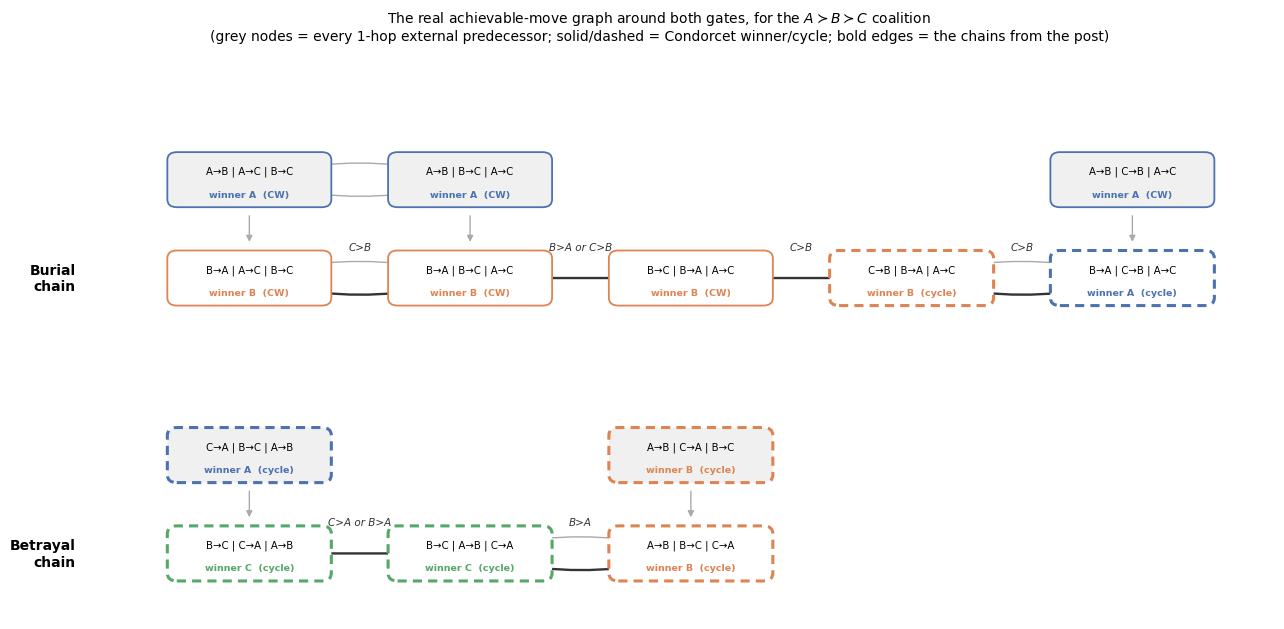

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

WIN_COLOR = {'A': '#4C72B0', 'B': '#DD8452', 'C': '#55A868'}

def describe_lie(P, name, order):
    # every insincere vote that alone achieves this step (see achievable())
    if name == '(0,1)':
        w1, l1 = P[0]
        return f'{l1}>{w1}'
    (w_i, l_i), (w_j, l_j) = (P[0], P[1]) if name == '(1,2)' else (P[1], P[2])
    lies = []
    if prefers(order, l_i, w_i):
        lies.append(f'{w_i}>{l_i}')
    if prefers(order, w_j, l_j):
        lies.append(f'{l_j}>{w_j}')
    return ' or '.join(lies)

node_set = list(dict.fromkeys(chain_nodes + boundary))
GRAPH = LOCAL.subgraph(node_set)

# lay out each chain left-to-right on its own row, far enough apart that
# neither row collides with the other row's boundary nodes; each boundary
# node sits just above the (first) chain node it feeds into
BURIAL_Y, BETRAYAL_Y, X_STEP = 2.1, 0.0, 1.4
pos = {s: (i * X_STEP, BURIAL_Y) for i, s in enumerate(burial_chain)}
pos.update({s: (i * X_STEP, BETRAYAL_Y) for i, s in enumerate(betrayal_chain)})
stacked = {}
for p in boundary:
    target = next(s for pp, _, s in boundary_edges if pp == p)
    tx, ty = pos[target]
    k = stacked.get((tx, ty), 0)
    stacked[(tx, ty)] = k + 1
    pos[p] = (tx - 0.42 * k, ty + 0.75)

CHAIN_EDGES = set()
for chain in (burial_chain, betrayal_chain):
    for a, b in zip(chain, chain[1:]):
        CHAIN_EDGES.add((a, b))

fig, ax = plt.subplots(figsize=(13, 6.4))

for u, v, data in GRAPH.edges(data=True):
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    highlighted = (u, v) in CHAIN_EDGES
    reciprocal = GRAPH.has_edge(v, u)
    rad = 0.15 if reciprocal else 0.0
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2), shrinkA=26, shrinkB=26,
        connectionstyle=f'arc3,rad={rad}', arrowstyle='-|>',
        mutation_scale=13 if highlighted else 9,
        color='#333333' if highlighted else '#aaaaaa',
        linewidth=1.7 if highlighted else 1.0, zorder=2 if highlighted else 1))
    if highlighted:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        dx, dy = x2 - x1, y2 - y1
        label_y = my + 0.20 if abs(dy) < 1e-6 else my
        label_x = mx + (0.55 if abs(dy) > 1e-6 else 0)
        ax.text(label_x, label_y, describe_lie(u, data['sigma'], order_ABC),
                ha='center', va='bottom', fontsize=7.5, color='#333333', style='italic', zorder=5)

for s in node_set:
    x, y = pos[s]
    w, cyc = winner(s), is_cycle(s)
    ax.add_patch(FancyBboxPatch(
        (x - 0.5, y - 0.19), 1.0, 0.38,
        boxstyle="round,pad=0.02,rounding_size=0.06",
        linewidth=2.2 if cyc else 1.3,
        linestyle=(0, (3, 2)) if cyc else 'solid',
        edgecolor=WIN_COLOR[w], facecolor='white' if s in chain_nodes else '#f0f0f0', zorder=3))
    ax.text(x, y + 0.065, fmt_state(s), ha='center', va='center', fontsize=7.3, zorder=4)
    ax.text(x, y - 0.11, f"winner {w}" + ("  (cycle)" if cyc else "  (CW)"),
            ha='center', va='center', fontsize=6.8, color=WIN_COLOR[w], fontweight='bold', zorder=4)

ax.text(-1.1, BURIAL_Y, "Burial\nchain", ha='right', va='center', fontsize=10, fontweight='bold')
ax.text(-1.1, BETRAYAL_Y, "Betrayal\nchain", ha='right', va='center', fontsize=10, fontweight='bold')

xs = [x for x, y in pos.values()]
ys = [y for x, y in pos.values()]
ax.set_xlim(min(xs) - 1.3, max(xs) + 0.9)
ax.set_ylim(min(ys) - 0.5, max(ys) + 1.0)
ax.axis('off')
ax.set_title("The real achievable-move graph around both gates, for the $A \\succ B \\succ C$ coalition\n"
             "(grey nodes = every 1-hop external predecessor; solid/dashed = Condorcet winner/cycle; "
             "bold edges = the chains from the post)", fontsize=10)
plt.tight_layout()
plt.show()

## Why are only some Condorcet winners vulnerable?

In [10]:
def winner_of_pair(P, pair):
    return next(w for w, l in P if frozenset((w, l)) == pair)

def vulnerable_to_burial(s, order):
    # order = (Top, W, Bottom); W is s's sincere Condorcet winner. At G1 the
    # only concordant pair is Top-vs-Bottom and the only discordant pair in a
    # CW state is Top-vs-W, so the reachability lemma collapses to this
    top, w_cand, bottom = order
    top_bottom, top_w = frozenset((top, bottom)), frozenset((top, w_cand))
    return winner_of_pair(s, top_bottom) == top and slot_of(s, top_bottom) > slot_of(s, top_w)

order_CBA = ('C', 'B', 'A')  # the other coalition that ranks B as its middle choice
cw_b_states = [s for s in STATES if condorcet_winner(s) == 'B']
actual_ABC = {s for s in cw_b_states if s in admits_complex}
actual_CBA = {s for s in cw_b_states if s in by_order_c[order_CBA]}

check('closed-form rule exactly predicts which CW=B states are vulnerable to A>B>C',
      {s for s in cw_b_states if vulnerable_to_burial(s, order_ABC)} == actual_ABC)
check('...and exactly predicts vulnerability to the mirrored C>B>A coalition',
      {s for s in cw_b_states if vulnerable_to_burial(s, order_CBA)} == actual_CBA)

# generalize across all 3 possible Condorcet winners and their 2 flanking coalitions
all_match = True
for w_cand in CANDS:
    cw_states = [s for s in STATES if condorcet_winner(s) == w_cand]
    other1, other2 = [c for c in CANDS if c != w_cand]
    for order in [(other1, w_cand, other2), (other2, w_cand, other1)]:
        predicted = {s for s in cw_states if vulnerable_to_burial(s, order)}
        actual = {s for s in cw_states if s in by_order_c[order]}
        all_match &= (predicted == actual)
check('the rule generalizes to every Condorcet winner and both of its flanking coalitions', all_match)

safe = [s for s in cw_b_states if s not in actual_ABC and s not in actual_CBA]
check('the other 6 of 12 CW=B states are safe from both flanking coalitions', len(safe) == 6)

pd.DataFrame({
    'state': [fmt_state(s) for s in cw_b_states],
    'Top beats Bottom for A>B>C?': ['yes' if winner_of_pair(s, frozenset(('A','C'))) == 'A' else 'no' for s in cw_b_states],
    'A-C wider than A-B?': ['yes' if slot_of(s, frozenset(('A','C'))) > slot_of(s, frozenset(('A','B'))) else 'no' for s in cw_b_states],
    'vulnerable to': ['A>B>C' if s in actual_ABC else ('C>B>A' if s in actual_CBA else 'neither') for s in cw_b_states],
}).sort_values('vulnerable to').reset_index(drop=True)

,state,Top beats Bottom for A>B>C?,A-C wider than A-B?,vulnerable to
0,B→A | A→C | B→C,yes,yes,A>B>C
1,B→A | B→C | A→C,yes,yes,A>B>C
2,B→C | B→A | A→C,yes,yes,A>B>C
3,B→A | B→C | C→A,no,yes,C>B>A
4,B→C | B→A | C→A,no,yes,C>B>A
5,B→C | C→A | B→A,no,no,C>B>A
6,B→A | C→A | B→C,no,yes,neither
7,A→C | B→A | B→C,yes,no,neither
8,C→A | B→A | B→C,no,no,neither
9,A→C | B→C | B→A,yes,no,neither


## Full results

In [11]:
# every check in this notebook, in one place
assert all(r == 'PASS' for _, r in results)
pd.DataFrame(results, columns=['claim', 'result'])

,claim,result
0,Condorcet Stability: CW states have no profitable simple manipulation,PASS
1,A swap of the second kind is never profitable,PASS
2,"A (2,3) swap is never profitable",PASS
3,Voting your least favorite over your favorite is never profitable,PASS
4,"Brute-forced gates for A>B>C match the post's G1, G2 exactly",PASS
5,"12 total (state, coalition) profitable-simple-manipulation pairs",PASS
6,every one of them starts from a cyclic state,PASS
7,each cyclic state has a UNIQUE exploiting coalition,PASS
8,...covering all 12 cyclic states,PASS
9,every state trivially reaches itself,PASS
